# Fase 3: Semantic Embedding Extraction — MiniLM Multilingual

**Notebook ke-3** dari pipeline pelatihan model deteksi tulisan AI.

| Checkpoint | File | Keterangan |
|---|---|---|
| Input | `data_cleaned.parquet` | Output dari Notebook 1 (Preprocessing) |
| Output | `minilm_embeddings.npy` | Matriks embedding **L2-normalized** (N x 384, float32) |
| Index | `minilm_id_index.npy` | Array ID teks yang di-encode (untuk mapping ke Notebook 4) |

**Model yang digunakan:** `paraphrase-multilingual-MiniLM-L12-v2` (Sentence-Transformers)
- Mendukung 50+ bahasa termasuk Bahasa Indonesia dan Inggris
- Output: vektor 384 dimensi per teks, **L2-normalized** (penting untuk konsistensi inference)
- Backend: PyTorch (berjalan di CUDA GPU jika tersedia)

**Variabel yang dihasilkan notebook ini:**
- `df_data` — DataFrame (subset: `id`, `text_clean`, `source`)
- `embedding_model` — SentenceTransformer model yang sudah diload
- `embeddings` — numpy array (N x 384, L2-normalized) hasil encode

**Catatan Desain:**
- Proses ekstraksi dilakukan per-chunk dan disimpan ke `emb_chunks/` untuk ketahanan terhadap crash.
- Jika proses terputus, jalankan ulang — chunk yang sudah ada akan dilewati otomatis (resume).
- GPU diprioritaskan secara eksplisit; notebook akan memberi peringatan jika GPU tidak terdeteksi.
- **`normalize_embeddings=True`**: Semua embedding di-L2-normalize agar panjang vektor = 1.0.
  Ini memastikan skala embedding konsisten antara training dan inference di `detector_pipeline.py`.
- Output dimensi 384 (bukan 512 seperti USE-M) — ini dikonfigurasikan di Notebook 4 (Training).


In [24]:
import sys
import subprocess

# --- Cek dan install dependensi ---
def install_if_missing(package, import_name=None):
    name = import_name or package
    try:
        __import__(name)
        print(f"  [OK] {package}")
    except ImportError:
        print(f"  [INSTALL] {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"  [OK] {package} (baru diinstal)")

print("Memeriksa dependensi...")
install_if_missing("pandas")
install_if_missing("numpy")
install_if_missing("pyarrow")
install_if_missing("fastparquet")
install_if_missing("ipywidgets")
install_if_missing("matplotlib")
install_if_missing("sentence-transformers", "sentence_transformers")
install_if_missing("umap-learn", "umap")
install_if_missing("tqdm")

# --- Import semua library ---
import pandas as pd
import numpy as np
import json
import os
import gc
import time
from datetime import datetime
from pathlib import Path

import torch
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.rcParams["figure.dpi"] = 110

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import umap

print()
print("=" * 55)
print(f"  pandas           : {pd.__version__}")
print(f"  numpy            : {np.__version__}")
print(f"  torch            : {torch.__version__}")
print(f"  sentence-transformers : (terinstall)")
print("=" * 55)


Memeriksa dependensi...
  [OK] pandas
  [OK] numpy
  [OK] pyarrow
  [OK] fastparquet
  [OK] ipywidgets
  [OK] matplotlib
  [OK] sentence-transformers
  [OK] umap-learn
  [OK] tqdm

  pandas           : 2.3.3
  numpy            : 2.3.5
  torch            : 2.12.0+cu130
  sentence-transformers : (terinstall)


## 1. Deteksi GPU & Inisialisasi Device

Notebook ini menggunakan GPU secara eksplisit untuk mempercepat proses encoding.
Jika GPU tidak terdeteksi, proses akan tetap berjalan di CPU namun jauh lebih lambat.


In [25]:
# -------------------------------------------------------
# Deteksi GPU — wajib ada CUDA untuk performa optimal
# -------------------------------------------------------
print("=" * 55)
print("  DETEKSI DEVICE")
print("=" * 55)

if torch.cuda.is_available():
    DEVICE = "cuda"
    gpu_name   = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    vram_free  = (torch.cuda.get_device_properties(0).total_memory
                  - torch.cuda.memory_allocated(0)) / 1024**3
    print(f"  [GPU] {gpu_name}")
    print(f"  VRAM Total : {vram_total:.1f} GB")
    print(f"  VRAM Free  : {vram_free:.1f} GB")
    print(f"  CUDA Ver   : {torch.version.cuda}")
    print()
    print("  GPU terdeteksi — encoding akan berjalan di CUDA.")
else:
    DEVICE = "cpu"
    print()
    print("  [PERINGATAN] GPU tidak terdeteksi.")
    print("  Encoding akan berjalan di CPU — jauh lebih lambat.")
    print()
    print("  Pastikan PyTorch versi CUDA sudah terinstall:")
    print("    pip install torch --index-url https://download.pytorch.org/whl/cu121")

print()
print(f"  Device aktif : {DEVICE.upper()}")
print("=" * 55)


  DETEKSI DEVICE
  [GPU] NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM Total : 6.0 GB
  VRAM Free  : 5.6 GB
  CUDA Ver   : 13.0

  GPU terdeteksi — encoding akan berjalan di CUDA.

  Device aktif : CUDA


## 2. Load Data Checkpoint dari Fase 1

Memuat `data_cleaned.parquet` yang dihasilkan oleh Notebook 1.
Hanya kolom `id`, `text_clean`, dan `source` yang diperlukan untuk fase ini.


In [26]:
# -------------------------------------------------------
# Load checkpoint Fase 1
# -------------------------------------------------------
PARQUET_PATH = "data_cleaned.parquet"

assert os.path.exists(PARQUET_PATH), (
    f"File tidak ditemukan: {PARQUET_PATH}\n"
    f"Jalankan Notebook 1 (01_preprocessing.ipynb) terlebih dahulu."
)

print(f"Memuat {PARQUET_PATH}...")
t0 = time.time()
df_data = pd.read_parquet(PARQUET_PATH, columns=["id", "text_clean", "source"])
elapsed = time.time() - t0

print(f"  Selesai dalam {elapsed:.1f} detik")
print(f"  Shape     : {df_data.shape}")
print(f"  Kolom     : {list(df_data.columns)}")
print(f"  Distribusi source:")
print(df_data["source"].value_counts().to_string())
print()

# Pastikan tidak ada teks null
n_null = df_data["text_clean"].isna().sum()
if n_null > 0:
    print(f"  [PERINGATAN] {n_null} baris dengan text_clean null — akan diisi string kosong.")
    df_data["text_clean"] = df_data["text_clean"].fillna("")

print(f"  Total baris valid : {len(df_data):,}")


Memuat data_cleaned.parquet...
  Selesai dalam 1.7 detik
  Shape     : (100000, 3)
  Kolom     : ['id', 'text_clean', 'source']
  Distribusi source:
source
ai       50000
human    50000

  Total baris valid : 100,000


## 3. Inisialisasi Model MiniLM Multilingual

Model `paraphrase-multilingual-MiniLM-L12-v2` akan diunduh otomatis ke cache lokal
saat pertama kali dijalankan (~420 MB). Pada run berikutnya, model dimuat dari cache.

**Spesifikasi model:**
- Arsitektur : MiniLM-L12 (12 layer transformer)
- Bahasa      : 50+ bahasa termasuk Indonesian (id) dan English (en)
- Output      : vektor 384 dimensi per kalimat/teks
- Cache lokal : `~/.cache/torch/sentence_transformers/`


In [27]:
# -------------------------------------------------------
# Load model sentence-transformers ke device yang aktif
# -------------------------------------------------------
MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_DIM = 384

print(f"Memuat model: {MODEL_NAME}")
print(f"Device target: {DEVICE.upper()}")
print()

t0 = time.time()
embedding_model = SentenceTransformer(MODEL_NAME, device=DEVICE)
elapsed = time.time() - t0

print(f"  Model berhasil dimuat dalam {elapsed:.1f} detik")
print(f"  Device aktif model : {embedding_model.device}")
print(f"  Dimensi output     : {EMBEDDING_DIM}")
print()

# Verifikasi cepat dengan satu sampel
_test_vec = embedding_model.encode(["Ini adalah uji coba model."], convert_to_numpy=True)
assert _test_vec.shape == (1, EMBEDDING_DIM), f"Dimensi tidak sesuai: {_test_vec.shape}"
print(f"  [OK] Verifikasi output shape: {_test_vec.shape} — sesuai {EMBEDDING_DIM} dimensi")


Memuat model: paraphrase-multilingual-MiniLM-L12-v2
Device target: CUDA



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Model berhasil dimuat dalam 15.4 detik
  Device aktif model : cuda:0
  Dimensi output     : 384

  [OK] Verifikasi output shape: (1, 384) — sesuai 384 dimensi


## 4. Konfigurasi Ekstraksi Embedding

Atur parameter ekstraksi, lalu klik **Mulai Ekstraksi**.

- **Jumlah Sampel**: Berapa baris yang akan di-encode. Mulai dari 50K untuk prototipe.
- **Chunk Size**: Berapa baris per chunk yang disimpan ke disk (sistem resume).
- **Batch Size Encoding**: Berapa teks yang diproses GPU sekaligus per forward pass.
- Chunk yang sudah ada di `emb_chunks/` akan dilewati otomatis saat resume.


In [28]:
# -------------------------------------------------------
# Konstanta path
# -------------------------------------------------------
CHUNK_DIR       = Path("emb_chunks")
OUTPUT_NPY      = "minilm_embeddings.npy"
OUTPUT_ID_INDEX = "minilm_id_index.npy"

CHUNK_DIR.mkdir(exist_ok=True)

# -------------------------------------------------------
# Baca chunk yang sudah ada (untuk info resume)
# -------------------------------------------------------
existing_chunks = sorted(CHUNK_DIR.glob("chunk_*.npy"))
existing_chunk_count = len(existing_chunks)

# -------------------------------------------------------
# Widget definisi
# -------------------------------------------------------
_total_rows = len(df_data)

style    = {"description_width": "160px"}
layout_w = widgets.Layout(width="520px")

w_sample = widgets.IntSlider(
    value=min(50_000, _total_rows),
    min=1_000,
    max=_total_rows,
    step=1_000,
    description="Jumlah Sampel:",
    style=style, layout=layout_w,
    readout_format=",d"
)

w_chunk = widgets.IntSlider(
    value=10_000,
    min=1_000,
    max=50_000,
    step=1_000,
    description="Chunk Size:",
    style=style, layout=layout_w,
    readout_format=",d"
)

w_batch = widgets.IntSlider(
    value=128,
    min=32,
    max=512,
    step=32,
    description="Batch Size Encoding:",
    style=style, layout=layout_w,
    readout_format=",d"
)

btn_start  = widgets.Button(description="▶  Mulai Ekstraksi",
                             button_style="success",
                             layout=widgets.Layout(width="220px", height="40px"))
btn_clear  = widgets.Button(description="✕  Hapus Semua Chunk",
                             button_style="danger",
                             layout=widgets.Layout(width="220px", height="40px"))
out_status = widgets.Output()

resume_info = ""
if existing_chunk_count > 0:
    resume_info = (
        f"<b style='color:#e67e22'>[RESUME] {existing_chunk_count} chunk sudah ada di emb_chunks/. "
        f"Akan dilanjutkan dari chunk berikutnya.</b>"
    )
else:
    resume_info = "<b style='color:#27ae60'>Tidak ada chunk sebelumnya — akan mulai dari awal.</b>"

display(
    widgets.HTML(f"<div style='margin-bottom:8px'>{resume_info}</div>"),
    w_sample,
    w_chunk,
    w_batch,
    widgets.HBox([btn_start, btn_clear]),
    out_status
)


HTML(value="<div style='margin-bottom:8px'><b style='color:#e67e22'>[RESUME] 50 chunk sudah ada di emb_chunks/…

IntSlider(value=50000, description='Jumlah Sampel:', layout=Layout(width='520px'), max=100000, min=1000, reado…

IntSlider(value=10000, description='Chunk Size:', layout=Layout(width='520px'), max=50000, min=1000, readout_f…

IntSlider(value=128, description='Batch Size Encoding:', layout=Layout(width='520px'), max=512, min=32, readou…

Output()

## 5. Ekstraksi Embedding (Core Engine)

Cell ini mendefinisikan fungsi inti dan event handler untuk tombol di atas.
Jalankan cell ini, lalu klik **Mulai Ekstraksi** di widget di atas.

**Sistem chunk/resume:**
```
emb_chunks/
  chunk_0000_emb.npy   <- embedding chunk 0 (baris 0 s/d chunk_size-1)
  chunk_0000_ids.npy   <- array ID teks untuk chunk 0
  chunk_0001_emb.npy   <- embedding chunk 1
  chunk_0001_ids.npy   <- array ID teks untuk chunk 1
  ...
```
Setelah semua chunk selesai, file di-merge menjadi `minilm_embeddings.npy`
dan `minilm_id_index.npy`.


In [30]:
# -------------------------------------------------------
# Fungsi utama ekstraksi embedding dengan chunk/resume
# -------------------------------------------------------

def encode_chunk(texts, batch_size, model):
    """Encode list teks menjadi numpy array L2-normalized (N x 384, float32).
    
    PENTING: normalize_embeddings=True menghasilkan vektor unit (||v||=1.0).
    Ini HARUS konsisten antara training (di sini) dan inference (detector_pipeline.py).
    Tanpa normalisasi, skala embedding bisa berbeda antar teks panjang vs pendek.
    """
    vecs = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True  # L2-normalize: panjang vektor = 1.0
    )
    return vecs.astype(np.float32)


def get_chunk_paths(chunk_idx):
    """Kembalikan path file embedding dan ID untuk satu chunk."""
    emb_path = CHUNK_DIR / f"chunk_{chunk_idx:04d}_emb.npy"
    ids_path  = CHUNK_DIR / f"chunk_{chunk_idx:04d}_ids.npy"
    return emb_path, ids_path


def chunk_exists(chunk_idx):
    emb_path, ids_path = get_chunk_paths(chunk_idx)
    return emb_path.exists() and ids_path.exists()


def merge_chunks(out_status_widget):
    """Merge semua chunk menjadi satu file .npy dan simpan."""
    with out_status_widget:
        print()
        print("Menggabungkan semua chunk...")

    chunk_files = sorted(CHUNK_DIR.glob("chunk_*_emb.npy"))
    id_files    = sorted(CHUNK_DIR.glob("chunk_*_ids.npy"))

    all_embs = [np.load(f) for f in chunk_files]
    all_ids  = [np.load(f, allow_pickle=True) for f in id_files]  # IDs are object arrays (strings)

    merged_emb = np.concatenate(all_embs, axis=0)
    merged_ids = np.concatenate(all_ids,  axis=0)

    np.save(OUTPUT_NPY,      merged_emb)
    np.save(OUTPUT_ID_INDEX, merged_ids)

    size_mb = os.path.getsize(OUTPUT_NPY) / 1024**2

    with out_status_widget:
        print(f"  [OK] {OUTPUT_NPY} — shape: {merged_emb.shape}, ukuran: {size_mb:.1f} MB")
        print(f"  [OK] {OUTPUT_ID_INDEX} — {len(merged_ids):,} ID tersimpan")

    return merged_emb, merged_ids


# -------------------------------------------------------
# Handler tombol "Hapus Semua Chunk"
# -------------------------------------------------------
def on_clear_chunks(b):
    with out_status:
        clear_output(wait=True)
        chunks = list(CHUNK_DIR.glob("chunk_*.npy"))
        if not chunks:
            print("Tidak ada chunk untuk dihapus.")
            return
        for f in chunks:
            os.remove(f)
        print(f"{len(chunks)} chunk berhasil dihapus. Siap mulai dari awal.")

btn_clear.on_click(on_clear_chunks)


# -------------------------------------------------------
# Handler tombol "Mulai Ekstraksi"
# -------------------------------------------------------
def on_start_encoding(b):
    btn_start.disabled = True
    btn_clear.disabled = True

    with out_status:
        clear_output(wait=True)

        n_sample   = w_sample.value
        chunk_size = w_chunk.value
        batch_size = w_batch.value

        # Ambil subset data
        df_sub = df_data.sample(n=min(n_sample, len(df_data)), random_state=42).reset_index(drop=True)
        # PENTING: Gunakan row_id (id_source) karena 'id' tidak unik (1 ID punya versi AI & Human)
        ids_arr   = (df_sub["id"].astype(str) + "_" + df_sub["source"].astype(str)).values
        texts_arr = df_sub["text_clean"].values
        n_total   = len(df_sub)

        n_chunks = (n_total + chunk_size - 1) // chunk_size

        print("=" * 55)
        print(f"  MULAI EKSTRAKSI EMBEDDING")
        print("=" * 55)
        print(f"  Total teks    : {n_total:,}")
        print(f"  Chunk size    : {chunk_size:,}")
        print(f"  Total chunk   : {n_chunks}")
        print(f"  Batch encode  : {batch_size}")
        print(f"  Device        : {DEVICE.upper()}")
        print(f"  Output file   : {OUTPUT_NPY}")
        print("=" * 55)
        print()

        t_global_start = time.time()
        chunks_done    = 0
        chunks_skipped = 0

        for chunk_idx in range(n_chunks):
            start = chunk_idx * chunk_size
            end   = min(start + chunk_size, n_total)

            emb_path, ids_path = get_chunk_paths(chunk_idx)

            if chunk_exists(chunk_idx):
                print(f"  [SKIP] Chunk {chunk_idx:04d}/{n_chunks-1:04d} "
                      f"(baris {start:,}–{end:,}) — sudah ada, dilewati.")
                chunks_skipped += 1
                continue

            # Encode
            t_chunk_start = time.time()
            chunk_texts   = texts_arr[start:end].tolist()
            chunk_ids     = ids_arr[start:end]

            chunk_emb = encode_chunk(chunk_texts, batch_size, embedding_model)

            # Simpan ke disk segera
            np.save(emb_path, chunk_emb)
            np.save(ids_path, chunk_ids)

            t_chunk = time.time() - t_chunk_start
            t_total = time.time() - t_global_start
            remaining_chunks = n_chunks - chunk_idx - 1
            eta_sec = (t_chunk * remaining_chunks) if remaining_chunks > 0 else 0
            eta_str = f"{int(eta_sec//60)}m {int(eta_sec%60)}s"

            chunks_done += 1
            print(f"  [DONE] Chunk {chunk_idx:04d}/{n_chunks-1:04d} "
                  f"(baris {start:,}–{end:,}) | "
                  f"{t_chunk:.1f}s | ETA: {eta_str}")

        # Merge semua chunk
        print()
        embeddings, id_index = merge_chunks(out_status)

        t_total_elapsed = time.time() - t_global_start
        print()
        print("=" * 55)
        print(f"  EKSTRAKSI SELESAI")
        print("=" * 55)
        print(f"  Chunk baru    : {chunks_done}")
        print(f"  Chunk dilewati: {chunks_skipped}")
        print(f"  Total waktu   : {int(t_total_elapsed//60)}m {int(t_total_elapsed%60)}s")
        print(f"  Shape final   : {embeddings.shape}")
        print()

    btn_start.disabled = False
    btn_clear.disabled = False

btn_start.on_click(on_start_encoding)


## 6. Load Embedding Hasil (untuk Analisis & Visualisasi)

Jika proses ekstraksi sudah selesai sebelumnya dan file `.npy` sudah ada,
jalankan cell ini untuk memuat langsung tanpa perlu encode ulang.


In [ ]:
# -------------------------------------------------------
# Load embedding dari file yang sudah tersimpan
# -------------------------------------------------------
assert os.path.exists(OUTPUT_NPY), (
    f"File {OUTPUT_NPY} belum ada.\n"
    f"Jalankan proses Ekstraksi Embedding di atas terlebih dahulu."
)
assert os.path.exists(OUTPUT_ID_INDEX), (
    f"File {OUTPUT_ID_INDEX} belum ada.\n"
    f"Jalankan proses Ekstraksi Embedding di atas terlebih dahulu."
)

embeddings = np.load(OUTPUT_NPY)
id_index   = np.load(OUTPUT_ID_INDEX, allow_pickle=True)

size_mb = os.path.getsize(OUTPUT_NPY) / 1024**2

print("=" * 55)
print("  EMBEDDING DIMUAT")
print("=" * 55)
print(f"  File         : {OUTPUT_NPY}")
print(f"  Shape        : {embeddings.shape}  (N x 384)")
print(f"  dtype        : {embeddings.dtype}")
print(f"  Ukuran file  : {size_mb:.1f} MB")
print(f"  ID index     : {len(id_index):,} entri")
print()

# Statistik embedding
print(f"  Min value    : {embeddings.min():.4f}")
print(f"  Max value    : {embeddings.max():.4f}")
print(f"  Mean         : {embeddings.mean():.4f}")
print(f"  Std dev      : {embeddings.std():.4f}")
print("=" * 55)

# Verifikasi L2 normalisasi — setiap baris harus punya norm ≈ 1.0
norms = np.linalg.norm(embeddings[:100], axis=1)
print(f"\n  Verifikasi L2 normalisasi (100 sampel pertama):")
print(f"  Norm mean  : {norms.mean():.6f} (harus ≈ 1.0)")
print(f"  Norm std   : {norms.std():.6f} (harus ≈ 0.0)")
if abs(norms.mean() - 1.0) < 0.01:
    print(f"  [OK] Embedding sudah L2-normalized.")
else:
    print(f"  [PERINGATAN] Embedding BELUM L2-normalized! Jalankan ulang ekstraksi.")
print("=" * 55)

# Rebuild df_sub untuk visualisasi (join berdasarkan row_id)
df_data["row_id"] = df_data["id"].astype(str) + "_" + df_data["source"].astype(str)
df_viz = df_data[df_data["row_id"].isin(id_index)].set_index("row_id").loc[id_index].reset_index()
print(f"\n  df_viz shape : {df_viz.shape}")
print(f"  Source dist  : {df_viz['source'].value_counts().to_dict()}")


  EMBEDDING DIMUAT
  File         : minilm_embeddings.npy
  Shape        : (50000, 384)  (N x 384)
  dtype        : float32
  Ukuran file  : 73.2 MB
  ID index     : 50,000 entri

  Min value    : -0.2639
  Max value    : 0.2604
  Mean         : -0.0000
  Std dev      : 0.0510

  Verifikasi L2 normalisasi (100 sampel pertama):
  Norm mean  : 1.000000 (harus ≈ 1.0)
  Norm std   : 0.000000 (harus ≈ 0.0)
  [OK] Embedding sudah L2-normalized.

  df_viz shape : (50000, 4)
  Source dist  : {'ai': 25199, 'human': 24801}


## 7. Visualisasi UMAP — Cluster Embedding

UMAP (Uniform Manifold Approximation and Projection) digunakan untuk mereduksi
384 dimensi ke 2 dimensi agar bisa divisualisasikan.

Plot ini menunjukkan seberapa baik model MiniLM memisahkan teks AI vs Human
dalam ruang embedding — tanpa training klasifikasi apapun.

**Parameter UMAP:**
- `n_neighbors` : kontrol keseimbangan struktur lokal vs global (default 15)
- `min_dist`    : kepadatan titik pada plot (default 0.1)
- `n_components`: dimensi output (2 untuk 2D plot)
- `metric`      : `cosine` — sesuai dengan embedding sentence-transformers


Mengambil 2000 sampel untuk visualisasi UMAP...
  AI samples    : 1000
  Human samples : 1000

Menjalankan UMAP (n_neighbors=15, metric=cosine)...


/home/nomnom/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP selesai dalam 10.6 detik
  Shape output: (2000, 2)



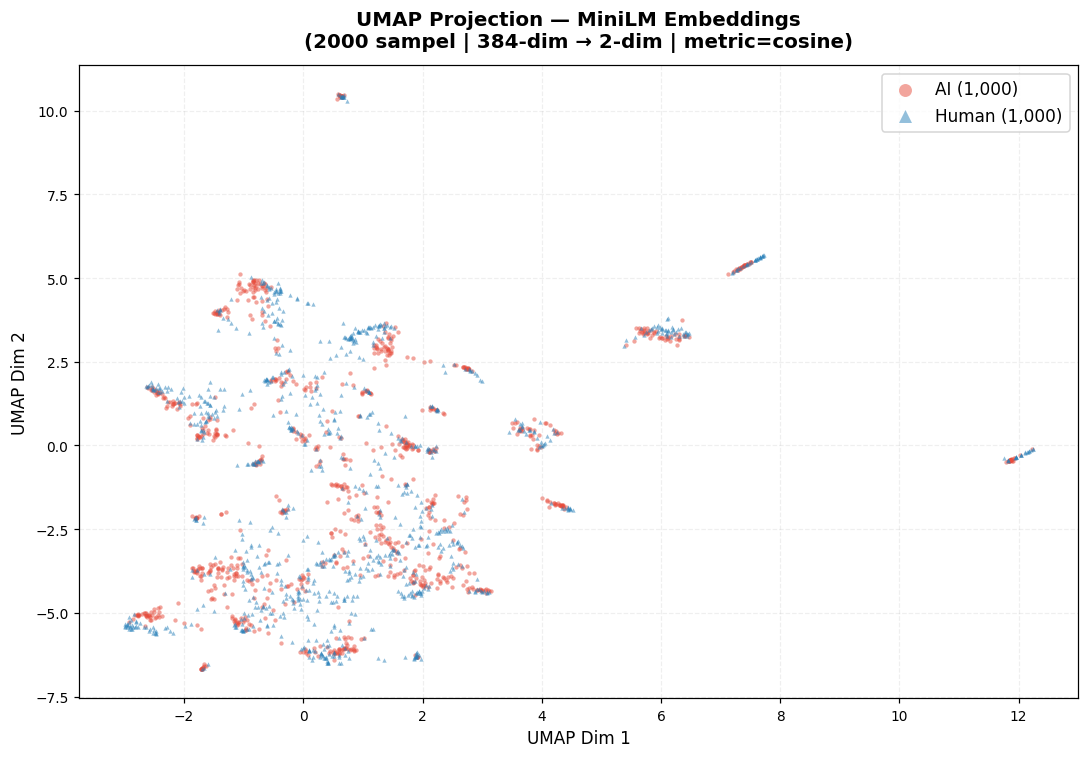

  Plot disimpan: umap_embedding_viz.png


In [ ]:
# -------------------------------------------------------
# UMAP Visualization — 2D projection dari 384-dim embeddings
# -------------------------------------------------------
N_VIZ    = min(2_000, len(embeddings))  # Subsample agar UMAP cepat
SEED     = 42

print(f"Mengambil {N_VIZ} sampel untuk visualisasi UMAP...")

# Ambil sampel seimbang (balance AI vs Human)
idx_ai    = np.where(df_viz["source"].values == "ai")[0]
idx_human = np.where(df_viz["source"].values == "human")[0]
n_each    = N_VIZ // 2

rng = np.random.default_rng(SEED)
idx_ai_sub    = rng.choice(idx_ai,    size=min(n_each, len(idx_ai)),    replace=False)
idx_human_sub = rng.choice(idx_human, size=min(n_each, len(idx_human)), replace=False)
idx_sub       = np.concatenate([idx_ai_sub, idx_human_sub])

emb_sub    = embeddings[idx_sub]
labels_sub = df_viz["source"].values[idx_sub]

print(f"  AI samples    : {(labels_sub == 'ai').sum()}")
print(f"  Human samples : {(labels_sub == 'human').sum()}")
print()

# --- UMAP ---
print("Menjalankan UMAP (n_neighbors=15, metric=cosine)...")
t0 = time.time()
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=SEED,
    verbose=False
)
emb_2d = reducer.fit_transform(emb_sub)
print(f"  UMAP selesai dalam {time.time()-t0:.1f} detik")
print(f"  Shape output: {emb_2d.shape}")
print()

# --- Plot ---
COLOR_AI    = "#e74c3c"   # merah
COLOR_HUMAN = "#2980b9"   # biru

fig, ax = plt.subplots(figsize=(10, 7))

for label, color, marker in [("ai", COLOR_AI, "o"), ("human", COLOR_HUMAN, "^")]:
    mask = labels_sub == label
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=color, marker=marker,
        s=8, alpha=0.5, linewidths=0,
        label=f"{'AI' if label == 'ai' else 'Human'} ({mask.sum():,})"
    )

ax.set_title(
    f"UMAP Projection — MiniLM Embeddings\n"
    f"({N_VIZ} sampel | 384-dim → 2-dim | metric=cosine)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("UMAP Dim 1", fontsize=11)
ax.set_ylabel("UMAP Dim 2", fontsize=11)
ax.legend(fontsize=11, markerscale=3)
ax.tick_params(labelsize=9)
ax.grid(True, alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("umap_embedding_viz.png", dpi=130, bbox_inches="tight")
plt.show()
print("  Plot disimpan: umap_embedding_viz.png")


## 8. Ringkasan Checkpoint & Langkah Selanjutnya

Jalankan cell ini untuk memastikan semua output fase ini sudah tersimpan
dan siap digunakan oleh Notebook 4 (Model Training).


In [ ]:
# -------------------------------------------------------
# Ringkasan status checkpoint Fase 3
# -------------------------------------------------------
files_to_check = {
    "minilm_embeddings.npy"  : "Matriks embedding (N x 384, float32)",
    "minilm_id_index.npy"    : "Array ID teks yang di-encode",
    "umap_embedding_viz.png" : "Plot UMAP 2D (opsional, untuk analisis)",
    "data_cleaned.parquet"   : "Checkpoint Fase 1 — digunakan Notebook 4",
    "features_structural.parquet": "Checkpoint Fase 2 — digunakan Notebook 4",
    "feature_config.json"    : "Konfigurasi 29 fitur — digunakan Notebook 4",
}

print("=" * 65)
print("  RINGKASAN CHECKPOINT FASE 3")
print("=" * 65)

all_ok = True
for fname, desc in files_to_check.items():
    exists = os.path.exists(fname)
    if exists:
        size_mb = os.path.getsize(fname) / 1024**2
        status  = f"[OK]  {size_mb:>8.1f} MB"
    else:
        status  = "[MISS]          —"
        if fname in ("minilm_embeddings.npy", "minilm_id_index.npy"):
            all_ok = False
    print(f"  {status}  {fname}")
    print(f"           {desc}")

print()
print("=" * 65)
if all_ok:
    print("  FASE 3 SELESAI — Siap lanjut ke Notebook 4 (Model Training)")
    print()
    print("  Catatan untuk Notebook 4:")
    print(f"    - Input dimensi structural : 29 fitur (akan di-StandardScaler di NB4)")
    print(f"    - Input dimensi embedding  : 384 (MiniLM, L2-normalized)")
    print(f"    - Total dimensi input      : 413")
    print(f"    - File embedding           : minilm_embeddings.npy (L2-normalized)")
    print(f"    - File ID index            : minilm_id_index.npy")
    print(f"    - PENTING: detector_pipeline.py harus juga normalize_embeddings=True")
else:
    print("  [PERHATIAN] Beberapa file output belum ada.")
    print("  Pastikan proses Ekstraksi Embedding sudah selesai.")
print("=" * 65)


  RINGKASAN CHECKPOINT FASE 3
  [OK]      73.2 MB  minilm_embeddings.npy
           Matriks embedding (N x 384, float32)
  [OK]       2.1 MB  minilm_id_index.npy
           Array ID teks yang di-encode
  [OK]       0.1 MB  umap_embedding_viz.png
           Plot UMAP 2D (opsional, untuk analisis)
  [OK]     105.0 MB  data_cleaned.parquet
           Checkpoint Fase 1 — digunakan Notebook 4
  [OK]      10.0 MB  features_structural.parquet
           Checkpoint Fase 2 — digunakan Notebook 4
  [OK]       0.0 MB  feature_config.json
           Konfigurasi 29 fitur — digunakan Notebook 4

  FASE 3 SELESAI — Siap lanjut ke Notebook 4 (Model Training)

  Catatan untuk Notebook 4:
    - Input dimensi structural : 29 fitur (akan di-StandardScaler di NB4)
    - Input dimensi embedding  : 384 (MiniLM, L2-normalized)
    - Total dimensi input      : 413
    - File embedding           : minilm_embeddings.npy (L2-normalized)
    - File ID index            : minilm_id_index.npy
    - PENTING: detector_